### Анализ тональности

#### Загрузка данных и пакетов

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('Corona_NLP_train.csv', encoding='latin-1')
df.head()

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,3799,48751,London,16-03-2020,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,3800,48752,UK,16-03-2020,advice Talk to your neighbours family to excha...,Positive
2,3801,48753,Vagabonds,16-03-2020,Coronavirus Australia: Woolworths to give elde...,Positive
3,3802,48754,NaN,16-03-2020,My food stock is not the only one which is emp...,Positive
4,3803,48755,NaN,16-03-2020,"Me, ready to go at supermarket during the #COV...",Extremely Negative


In [2]:
df.shape

(41157, 6)

#### Вывод случайных значений

In [3]:
df.sample(10)

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
31368,35167,80119,"San Francisco, CA",06-04-2020,3/ This could depress real-time prices and cau...,Positive
6553,10352,55304,"Brooksville, FL",19-03-2020,Working overtime to replenish the depleting st...,Negative
7446,11245,56197,West Virginia,19-03-2020,Please tell me the wine store is considered Â...,Positive
17630,21429,66381,"Exeter, England",23-03-2020,All this time indoors and I've finally overcom...,Extremely Positive
19346,23145,68097,"Tottenham, Haringey",24-03-2020,HARINGEY! \r\r\n\r\r\nIf you see any store hik...,Positive
5094,8893,53845,"Nyon, Switzerland",18-03-2020,Spanish unions secure better protections for s...,Positive
25493,29292,74244,"Kent, UK",31-03-2020,WATCH AGAIN: Demand at a #Kent food bank has q...,Positive
8467,12266,57218,Available in US & Canada,19-03-2020,COVID-19 &amp; Its Effects on Scrap Metal &amp...,Neutral
35188,38987,83939,NaN,08-04-2020,"@Amamitsubasa000 If u want to go supermarket, ...",Positive
36772,40571,85523,"Manitoba, Canada",10-04-2020,Manitoba farmers market offering online shoppi...,Neutral


In [4]:
df.isnull().sum()

UserName            0
ScreenName          0
Location         8590
TweetAt             0
OriginalTweet       0
Sentiment           0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df = df[['OriginalTweet', 'Sentiment']]
df.head()

,OriginalTweet,Sentiment
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral
1,advice Talk to your neighbours family to excha...,Positive
2,Coronavirus Australia: Woolworths to give elde...,Positive
3,My food stock is not the only one which is emp...,Positive
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative


#### Визуализация

Sentiment
Positive              11422
Negative               9917
Neutral                7713
Extremely Positive     6624
Extremely Negative     5481
Name: count, dtype: int64


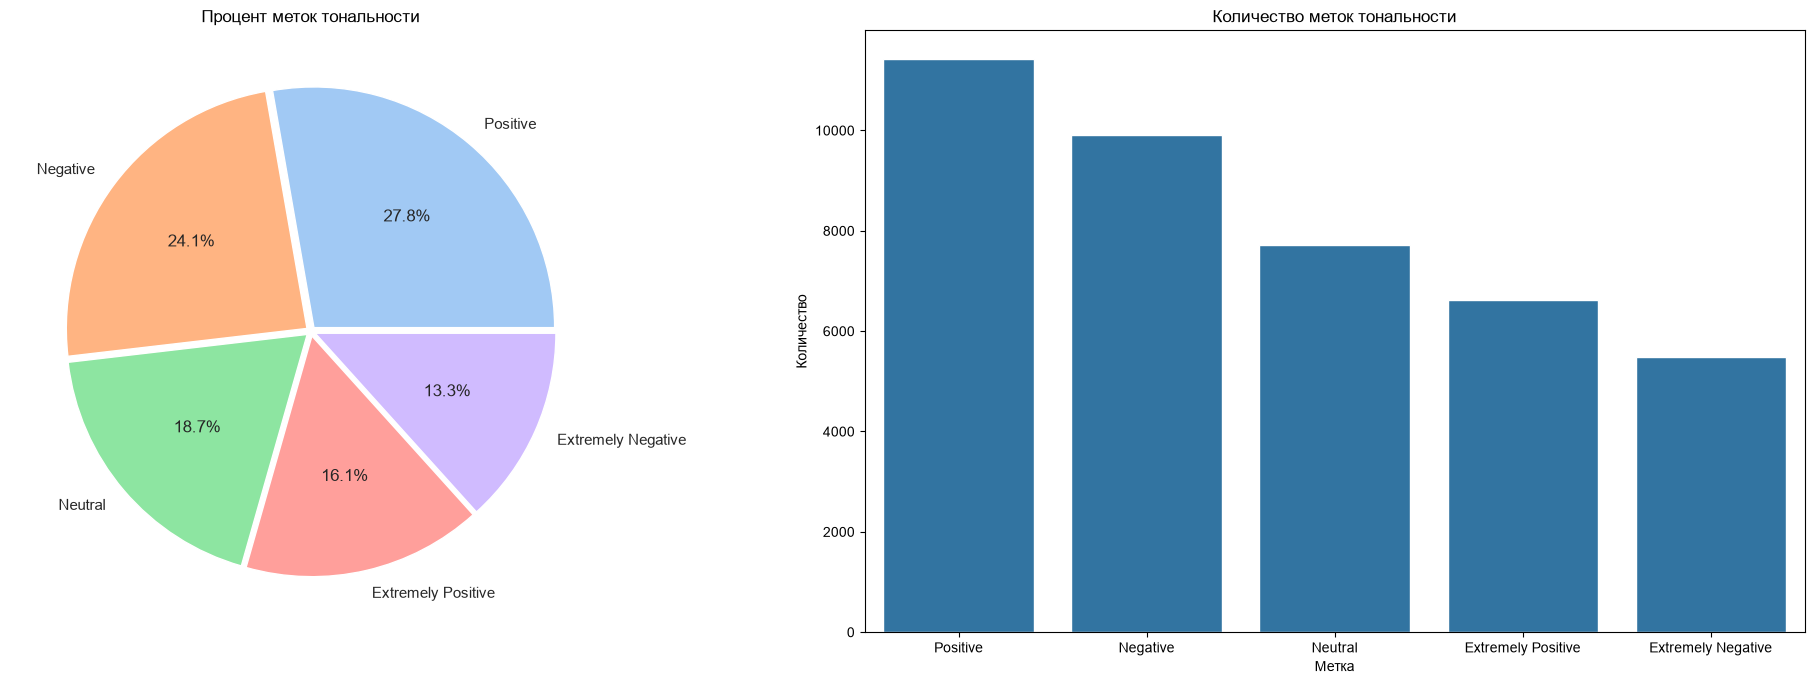

In [7]:
label_count = df['Sentiment'].value_counts()
print(label_count)


fig, axes = plt.subplots(nrows=1, ncols=2, figsize = (20,7))
sns.set_theme(style='darkgrid', palette='pastel')
color = sns.color_palette(palette='pastel')
explode = [0.02] * len(label_count)

axes[0].pie(label_count.values, labels = label_count.index, autopct='%1.1f%%', 
            colors = color, explode=explode)
axes[0].set_title('Процент меток тональности')

sns.barplot(x=label_count.index, y=label_count.values, ax=axes[1])
axes[1].set_title('Количество меток тональности')
axes[1].set_xlabel('Метка')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()


#### Подсчет длины сообщений

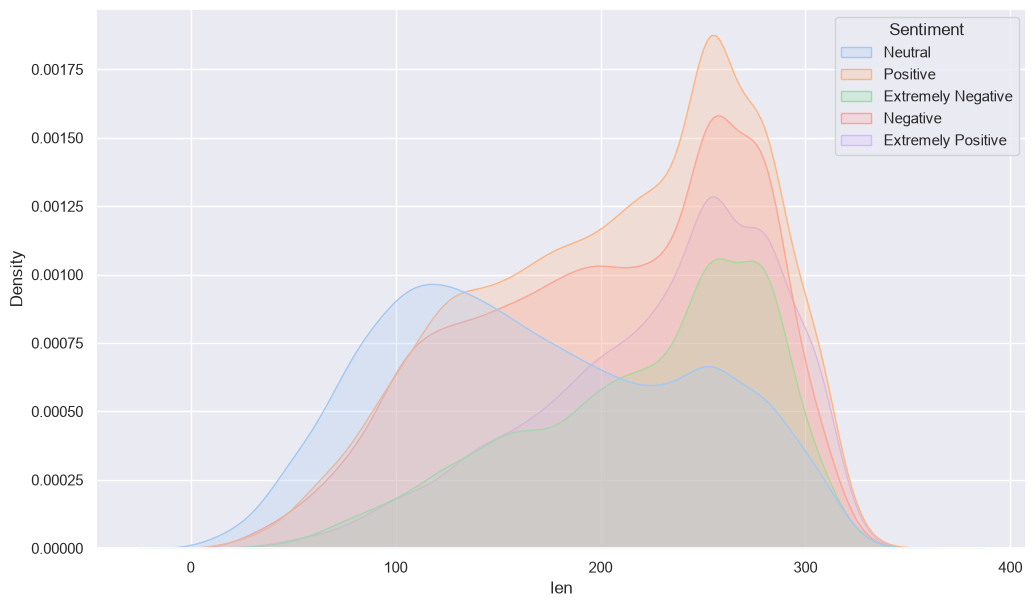

In [8]:
df['len'] = df['OriginalTweet'].apply(len)

plt.figure(figsize=(12, 7))
sns.kdeplot(df, x='len', fill=True, hue='Sentiment')
plt.show()

#### BoW, Bag of Words, Мешок слов

In [9]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer()
matrix = cv.fit_transform(df['OriginalTweet'])

In [10]:
matrix

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 1149620 stored elements and shape (41157, 80424)>

In [11]:
matrix.toarray()

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [2, 0, 0, ..., 0, 0, 0]], shape=(41157, 80424))

In [12]:
cv.get_feature_names_out()[67045:67055]

array(['sumantranaik', 'sumbangkan', 'sumer', 'suministros', 'sumitomo',
       'summa', 'summarise', 'summarize', 'summarized', 'summarizes'],
      dtype=object)

In [13]:
word_matrix = pd.DataFrame(matrix.toarray(), columns=cv.get_feature_names_out())

#### Часто встречащиеся слова

In [14]:
df_sum = word_matrix.sum(axis=0, skipna=True)
bow = df_sum.sort_values(ascending=False)[:30]

In [15]:
bow

the            44869
to             38474
co             24121
and            24093
https          24007
of             21547
in             19316
coronavirus    18154
for            14059
19             12597
is             12262
covid          12192
are            11349
you             9717
on              9440
this            7994
prices          7939
at              7850
food            7164
supermarket     7082
store           6917
we              6701
with            6637
it              6636
that            6504
grocery         6283
have            6162
as              6110
be              5753
people          5574
dtype: int64

In [16]:
bow = pd.DataFrame(bow, columns=['Frequncy'])
bow

,Frequncy
the,44869
to,38474
co,24121
and,24093
https,24007
of,21547
in,19316
coronavirus,18154
for,14059
19,12597


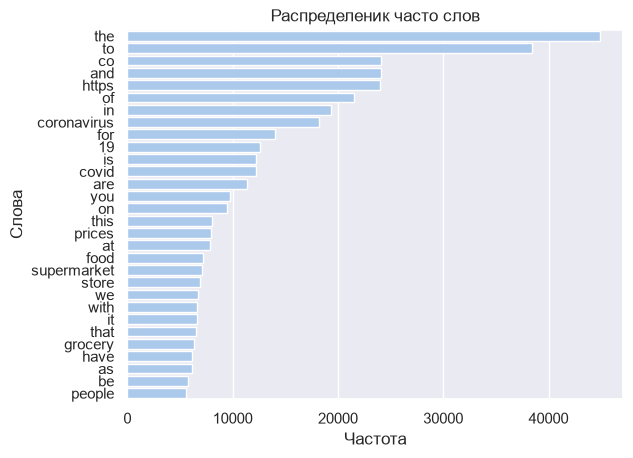

In [17]:
sns.barplot(x=bow['Frequncy'], y=bow.index)
plt.xlabel('Частота')
plt.ylabel('Слова')
plt.title('Распределеник часто слов')
plt.show()

#### Очистка данных

In [18]:
import string
import nltk
import re
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/artemgolubnichiy/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
stopwords = nltk.corpus.stopwords.words('english')

In [20]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"@\S+", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"pic.\S+", "", text)
    text = re.sub(r"[^a-z'A-Z]", " ", text)
    text = re.sub(r"\s+ [a-z'A-Z]", " ", text+ " ")
    text = ''.join([i for i in text if i not in string.punctuation])
    words = nltk.tokenize.word_tokenize(text)
    text = ' '.join([i for i in words if i not in stopwords and len(i) > 2])
    text = re.sub("\s[\s]+", " ", text).strip()
    return text


In [21]:
df['new_text'] = df['OriginalTweet'].apply(clean_text)

In [22]:
df

,OriginalTweet,Sentiment,len,new_text
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,111,
1,advice Talk to your neighbours family to excha...,Positive,237,advice talk neighbours family exchange phone n...
2,Coronavirus Australia: Woolworths to give elde...,Positive,131,coronavirus australia oolworths give elderly i...
3,My food stock is not the only one which is emp...,Positive,306,food stock one empty lease ont panic enough fo...
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,310,eady supermarket ovid utbreak paranoid food st...
...,...,...,...,...
41152,Airline pilots offering to stock supermarket s...,Neutral,102,airline pilots offering stock supermarket shel...
41153,Response to complaint not provided citing COVI...,Extremely Negative,138,response complaint provided citing covid elate...
41154,You know itÂs getting tough when @KameronWild...,Positive,136,know getting tough rationing toilet paper oron...
41155,Is it wrong that the smell of hand sanitizer i...,Neutral,111,wrong smell hand sanitizer starting turn orona...


#### Стемминг

In [23]:
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

ps = PorterStemmer()
words = word_tokenize(df['new_text'].iloc[1])
for w in words:
    print(w, ":", ps.stem(w))

advice : advic
talk : talk
neighbours : neighbour
family : famili
exchange : exchang
phone : phone
numbers : number
create : creat
contact : contact
list : list
phone : phone
numbers : number
neighbours : neighbour
schools : school
employer : employ
chemist : chemist
set : set
online : onlin
shopping : shop
accounts : account
poss : poss
adequate : adequ
supplies : suppli
regular : regular
meds : med
order : order


In [24]:
stemmed = []
for i in range(len(df)):
    stem_list = []
    words = word_tokenize(df['new_text'].iloc[i])
    for w in words:
        stem_list.append(ps.stem(w))
    stemmed.append(stem_list)

df['Stemmed'] = stemmed

In [25]:
df

,OriginalTweet,Sentiment,len,new_text,Stemmed
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,111,,[]
1,advice Talk to your neighbours family to excha...,Positive,237,advice talk neighbours family exchange phone n...,"[advic, talk, neighbour, famili, exchang, phon..."
2,Coronavirus Australia: Woolworths to give elde...,Positive,131,coronavirus australia oolworths give elderly i...,"[coronaviru, australia, oolworth, give, elderl..."
3,My food stock is not the only one which is emp...,Positive,306,food stock one empty lease ont panic enough fo...,"[food, stock, one, empti, leas, ont, panic, en..."
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,310,eady supermarket ovid utbreak paranoid food st...,"[eadi, supermarket, ovid, utbreak, paranoid, f..."
...,...,...,...,...,...
41152,Airline pilots offering to stock supermarket s...,Neutral,102,airline pilots offering stock supermarket shel...,"[airlin, pilot, offer, stock, supermarket, she..."
41153,Response to complaint not provided citing COVI...,Extremely Negative,138,response complaint provided citing covid elate...,"[respons, complaint, provid, cite, covid, elat..."
41154,You know itÂs getting tough when @KameronWild...,Positive,136,know getting tough rationing toilet paper oron...,"[know, get, tough, ration, toilet, paper, oron..."
41155,Is it wrong that the smell of hand sanitizer i...,Neutral,111,wrong smell hand sanitizer starting turn orona...,"[wrong, smell, hand, sanit, start, turn, orona..."


In [26]:
df['Stemmed'] = df['Stemmed'].apply(' '.join)

In [27]:
df

,OriginalTweet,Sentiment,len,new_text,Stemmed
0,@MeNyrbie @Phil_Gahan @Chrisitv https://t.co/i...,Neutral,111,,
1,advice Talk to your neighbours family to excha...,Positive,237,advice talk neighbours family exchange phone n...,advic talk neighbour famili exchang phone numb...
2,Coronavirus Australia: Woolworths to give elde...,Positive,131,coronavirus australia oolworths give elderly i...,coronaviru australia oolworth give elderli isa...
3,My food stock is not the only one which is emp...,Positive,306,food stock one empty lease ont panic enough fo...,food stock one empti leas ont panic enough foo...
4,"Me, ready to go at supermarket during the #COV...",Extremely Negative,310,eady supermarket ovid utbreak paranoid food st...,eadi supermarket ovid utbreak paranoid food st...
...,...,...,...,...,...
41152,Airline pilots offering to stock supermarket s...,Neutral,102,airline pilots offering stock supermarket shel...,airlin pilot offer stock supermarket shelv loc...
41153,Response to complaint not provided citing COVI...,Extremely Negative,138,response complaint provided citing covid elate...,respons complaint provid cite covid elat delay...
41154,You know itÂs getting tough when @KameronWild...,Positive,136,know getting tough rationing toilet paper oron...,know get tough ration toilet paper oronaviru o...
41155,Is it wrong that the smell of hand sanitizer i...,Neutral,111,wrong smell hand sanitizer starting turn orona...,wrong smell hand sanit start turn oronaviru ov...


#### Классификация

In [28]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
X = df['Stemmed']
y, class_name = pd.factorize(df['Sentiment'], sort=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipe_1 = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifire', MultinomialNB(alpha=0.05))
])

pipe_1.fit(X_train, y_train)
y_pred = pipe_1.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_name))


0.4290573372206025
                    precision    recall  f1-score   support

Extremely Negative       0.55      0.28      0.37      1096
Extremely Positive       0.53      0.30      0.38      1325
          Negative       0.39      0.48      0.43      1983
           Neutral       0.59      0.34      0.43      1543
          Positive       0.38      0.59      0.46      2285

          accuracy                           0.43      8232
         macro avg       0.49      0.40      0.42      8232
      weighted avg       0.47      0.43      0.42      8232



#### Логистическая регрессия

In [30]:
from sklearn.linear_model import LogisticRegression
pipe_2 = Pipeline([
    ('vectorizer', TfidfVectorizer()),
    ('classifire', LogisticRegression(class_weight="balanced"))
])

pipe_2.fit(X_train, y_train)
y_pred = pipe_2.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=class_name))


0.5567298347910593
                    precision    recall  f1-score   support

Extremely Negative       0.56      0.70      0.62      1096
Extremely Positive       0.58      0.71      0.64      1325
          Negative       0.52      0.40      0.45      1983
           Neutral       0.56      0.74      0.64      1543
          Positive       0.56      0.40      0.47      2285

          accuracy                           0.56      8232
         macro avg       0.56      0.59      0.57      8232
      weighted avg       0.55      0.56      0.55      8232



/opt/anaconda3/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
